In [148]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import math



In [150]:
x, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    n_classes=2,
    random_state=42
)

In [190]:
x

array([[-3.15729171e-01, -4.62081561e-01],
       [-3.85715369e-01, -1.71952730e+00],
       [ 1.02310692e+00,  6.48278046e-01],
       [ 7.38170470e-01, -6.04105869e-01],
       [ 1.31473224e+00,  2.57334774e-02],
       [-1.22662445e+00, -6.82137018e-01],
       [-4.03334009e-01,  4.91529148e-01],
       [ 1.08895564e+00,  1.72229813e+00],
       [ 6.58892260e-01, -9.48689774e-01],
       [ 1.45331088e+00,  9.36290858e-01],
       [-1.43182296e+00, -3.78654089e-01],
       [ 8.37357215e-01, -6.99279974e-01],
       [-4.54673491e-01,  5.17022030e-01],
       [ 6.90501558e-01, -1.10000981e+00],
       [-1.80631594e+00,  1.58816636e+00],
       [ 8.94360667e-01,  8.87571747e-01],
       [-5.60262305e-01,  6.02765879e-01],
       [ 6.66072259e-01, -1.05771717e+00],
       [ 7.96813761e-01, -1.05358038e+00],
       [ 9.95011892e-01, -9.20249233e-01],
       [ 2.96383142e-03,  1.65717813e+00],
       [-1.36701819e+00, -1.38288394e-01],
       [ 1.02821177e+00, -6.30503647e-01],
       [ 8.

In [152]:
n_centers = 10 
rng = np.random.default_rng(0)

center_indices = rng.choice(
    x_train.shape[0],   
    n_centers,
    replace=False
)

rbf_centers = x_train[center_indices]  
rbf_width = 1.0  # sigma

print("center_indices:", center_indices)
print("rbf_centers shape:", rbf_centers.shape)


center_indices: [196 195 147 119  63   9   3  72  41  17]
rbf_centers shape: (10, 2)


In [158]:
scaler = StandardScaler()
x = scaler.fit_transform(x)


In [160]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (240, 2)
x_test shape: (60, 2)


In [162]:
n_centers = 10  

rng = np.random.default_rng(0)
center_indices = rng.choice(
    x_train.shape[0],   
    n_centers,
    replace=False
)

rbf_centers = x_train[center_indices]  
rbf_width = 1.0  

print("center_indices:", center_indices)
print("rbf_centers shape:", rbf_centers.shape)


center_indices: [196 195 147 119  63   9   3  72  41  17]
rbf_centers shape: (10, 2)


In [164]:
def gaussian_rbf(x_in, centers, sigma):
   
    dist_sq = cdist(x_in, centers, metric='sqeuclidean')
    phi = np.exp(- dist_sq / (2 * (sigma ** 2)))

    return phi

def rbf_layer(x_in, centers, sigma):
    return gaussian_rbf(x_in, centers, sigma)

# sanity check
phi_preview = rbf_layer(x_train[:5], rbf_centers, rbf_width)
print("phi_preview shape (5 samples -> n_centers):", phi_preview.shape)

phi_preview shape (5 samples -> n_centers): (5, 10)


In [166]:
phi_train = rbf_layer(x_train, rbf_centers, rbf_width)

In [168]:
model = LinearRegression()
model.fit(phi_train, y_train)


LinearRegression()

In [172]:
phi_test = rbf_layer(x_test, rbf_centers, rbf_width)
y_pred_cont = model.predict(phi_test)
y_pred_class = (y_pred_cont >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_class)
print(f"Test accuracy: {acc * 100:.2f}%")

Test accuracy: 95.00%


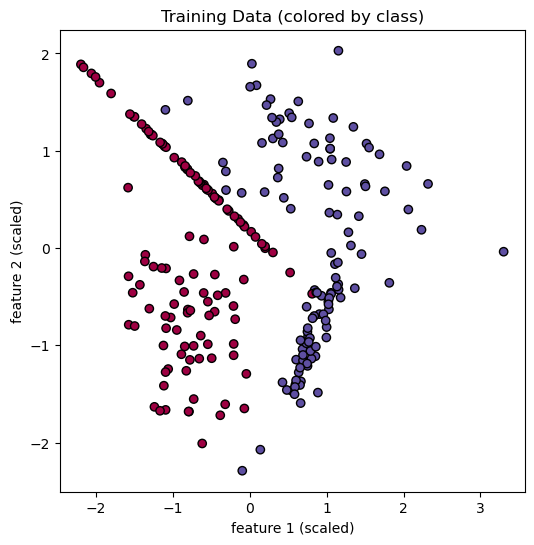

In [174]:
plt.figure(figsize=(6,6))
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    cmap=plt.cm.Spectral,
    edgecolor="black"
)
plt.title("Training Data (colored by class)")
plt.xlabel("feature 1 (scaled)")
plt.ylabel("feature 2 (scaled)")
plt.show()

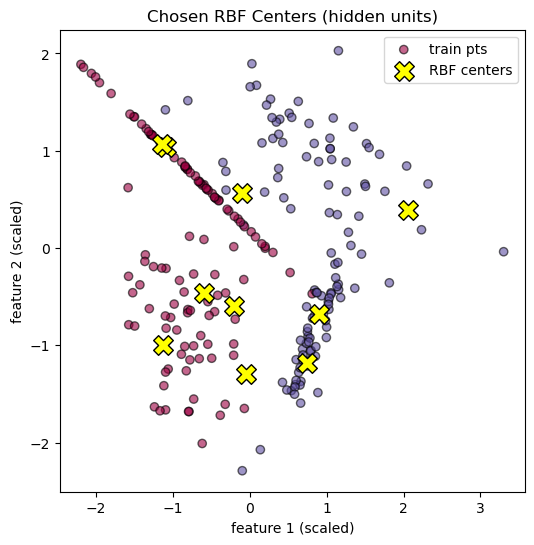

In [176]:
plt.figure(figsize=(6,6))

# plot training data
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    cmap=plt.cm.Spectral,
    edgecolor="black",
    alpha=0.6,
    label="train pts"
)

# plot chosen RBF centers
plt.scatter(
    rbf_centers[:, 0],
    rbf_centers[:, 1],
    marker="X",
    s=200,
    c="yellow",
    edgecolor="black",
    label="RBF centers"
)

plt.title("Chosen RBF Centers (hidden units)")
plt.xlabel("feature 1 (scaled)")
plt.ylabel("feature 2 (scaled)")
plt.legend()
plt.show()

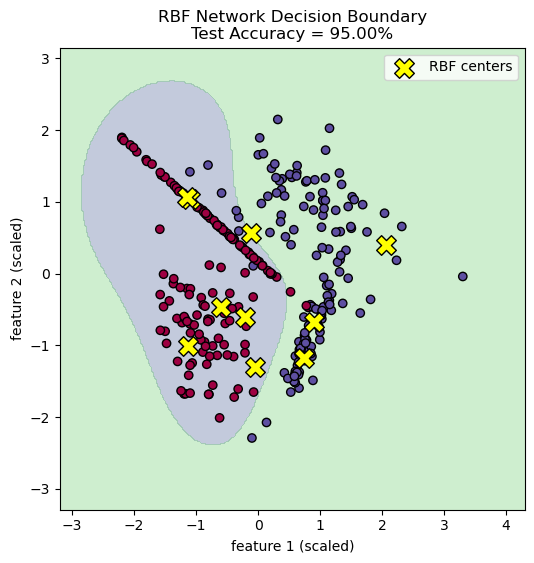

In [178]:
x_min, x_max = x[:, 0].min() - 1.0, x[:, 0].max() + 1.0
y_min, y_max = x[:, 1].min() - 1.0, x[:, 1].max() + 1.0

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# flatten grid to list of points, like [[x1,y1],[x2,y2],...]
grid_points = np.c_[xx.ravel(), yy.ravel()]

# RBF features for every grid point
phi_grid = rbf_layer(grid_points, rbf_centers, rbf_width)

# Predict on grid
z_cont = model.predict(phi_grid)
z_class = (z_cont >= 0.5).astype(int)
z_class = z_class.reshape(xx.shape)  # reshape back to 2D so we can contour plot

plt.figure(figsize=(6,6))

# background classification regions
plt.contourf(xx, yy, z_class, alpha=0.3, levels=[-1, 0, 1])

# plot all original samples
plt.scatter(
    x[:, 0],
    x[:, 1],
    c=y,
    cmap=plt.cm.Spectral,
    edgecolor="black"
)

# plot RBF centers again
plt.scatter(
    rbf_centers[:, 0],
    rbf_centers[:, 1],
    marker="X",
    s=200,
    c="yellow",
    edgecolor="black",
    label="RBF centers"
)

plt.title(f"RBF Network Decision Boundary\nTest Accuracy = {acc*100:.2f}%")
plt.xlabel("feature 1 (scaled)")
plt.ylabel("feature 2 (scaled)")
plt.legend()
plt.show()